# K-means

Here we'll explore **K Means Clustering**, which is an unsupervised clustering technique.

We'll start with our standard set of initial imports

In [24]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# use seaborn plotting defaults
import seaborn as sns; sns.set()

## Introducing K-Means

K Means is an algorithm for **unsupervised clustering**: that is, finding clusters in data based on the data attributes alone (not the labels).

K Means is a relatively easy-to-understand algorithm.  It searches for cluster centers which are the mean of the points within them, such that every point is closest to the cluster center it is assigned to.

Let's look at how KMeans operates on the simple clusters we looked at previously. To emphasize that this is unsupervised, we'll not plot the colors of the clusters:

In [25]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=300, centers=4,
                  random_state=0, cluster_std=0.60)
plt.scatter(X[:, 0], X[:, 1], s=50);
plt.xticks([]);
plt.yticks([]);

By eye, it is relatively easy to pick out the four clusters. If you were to perform an exhaustive search for the different segmentations of the data, however, the search space would be exponential in the number of points. Fortunately, there is a well-known *Expectation Maximization (EM)* procedure which scikit-learn implements, so that KMeans can be solved relatively quickly.

In [26]:
from sklearn.cluster import KMeans
est = KMeans(4, n_init=10)  # 4 clusters
est.fit(X)
y_kmeans = est.predict(X)
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='rainbow');
plt.xticks([]);
plt.yticks([]);

The algorithm identifies the four clusters of points in a manner very similar to what we would do by eye!

## The K-Means Algorithm: Expectation Maximization

K-Means is an example of an algorithm which uses an *Expectation-Maximization* approach to arrive at the solution.
*Expectation-Maximization* is a two-step approach which works as follows:

1. Guess some cluster centers
2. Repeat until converged

   * Assign points to the nearest cluster center
   * Set the cluster centers to the mean 
   
Let's quickly visualize this process. Ignore the cell below; it is only used to compute the animations.

In [27]:
import warnings


def plot_kmeans_interactive(min_clusters=1, max_clusters=6):
    from ipywidgets import interact
    from sklearn.metrics.pairwise import euclidean_distances

    with warnings.catch_warnings():
        warnings.filterwarnings('ignore')

        X, y = make_blobs(n_samples=300, centers=4,
                          random_state=0, cluster_std=0.60)
        def _kmeans_step(frame=0, n_clusters=4):
            rng = np.random.RandomState(2)
            labels = np.zeros(X.shape[0])
            centers = rng.randn(n_clusters, 2)

            nsteps = frame // 3

            for i in range(nsteps + 1):
                old_centers = centers
                if i < nsteps or frame % 3 > 0:
                    dist = euclidean_distances(X, centers)
                    labels = dist.argmin(1)

                if i < nsteps or frame % 3 > 1:
                    centers = np.array([X[labels == j].mean(0)
                                        for j in range(n_clusters)])
                    nans = np.isnan(centers)
                    centers[nans] = old_centers[nans]


            # plot the data and cluster centers
            plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='rainbow',
                        vmin=0, vmax=n_clusters - 1);
            plt.scatter(old_centers[:, 0], old_centers[:, 1], marker='o',
                        c=np.arange(n_clusters),
                        s=200, cmap='rainbow')
            plt.scatter(old_centers[:, 0], old_centers[:, 1], marker='o',
                        c='black', s=50)
                        
            plt.xticks([]);
            plt.yticks([]);

            # plot new centers if third frame
            if frame % 3 == 2:
                for i in range(n_clusters):
                    plt.annotate('', centers[i], old_centers[i], 
                                 arrowprops=dict(arrowstyle='->', linewidth=1))
                plt.scatter(centers[:, 0], centers[:, 1], marker='o',
                            c=np.arange(n_clusters),
                            s=200, cmap='rainbow')
                plt.scatter(centers[:, 0], centers[:, 1], marker='o',
                            c='black', s=50)

            plt.xlim(-4, 4)
            plt.ylim(-2, 10)

            if frame % 3 == 1:
                plt.text(3.8, 9.5, "1. Reassign points to nearest centroid",
                         ha='right', va='top', size=14)
            elif frame % 3 == 2:
                plt.text(3.8, 9.5, "2. Update centroids to cluster means",
                         ha='right', va='top', size=14)

    
    return interact(_kmeans_step, frame=range(1, 51),
                    n_clusters=range(min_clusters, max_clusters))


Observe the algorithm output frame by frame:

In [28]:
warnings.filterwarnings('ignore')
plot_kmeans_interactive();

interactive(children=(Dropdown(description='frame', options=(1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15…

This algorithm will (often) converge to the optimal cluster centers.

### KMeans Caveats

The convergence of this algorithm is not guaranteed; for that reason, scikit-learn by default uses a large number of random initializations and finds the best results.

Also, the number of clusters must be set beforehand... there are other clustering algorithms for which this requirement may be lifted.

## Application of KMeans to Digits

For a closer-to-real-world example, let's again take a look at the digits data. Here we'll use KMeans to automatically cluster the data in 64 dimensions, and then look at the cluster centers to see what the algorithm has found.

In [29]:
from sklearn.datasets import load_digits
digits = load_digits()

In [30]:
est = KMeans(n_clusters=10)
clusters = est.fit_predict(digits.data)
print(f"Clusters shape: {est.cluster_centers_.shape}")

Clusters shape: (10, 64)


We see ten clusters in 64 dimensions. Let's visualize each of these cluster centers to see what they represent:

In [31]:
fig = plt.figure(figsize=(8, 3))
for i in range(10):
    ax = fig.add_subplot(2, 5, 1 + i, xticks=[], yticks=[])
    ax.imshow(est.cluster_centers_[i].reshape((8, 8)), cmap=plt.cm.binary)

We see that *even without the labels*, KMeans is able to find clusters whose means are recognizable digits (with apologies to the number 8)!

The cluster labels are permuted; let's fix this:

In [32]:
from scipy.stats import mode

labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

For good measure, let's use our PCA visualization and look at the true cluster labels and K-means cluster labels:

In [33]:
from sklearn.decomposition import PCA

X = PCA(2).fit_transform(digits.data)

kwargs = dict(cmap = plt.cm.get_cmap('rainbow', 10),
              edgecolor='none', alpha=0.6)
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].scatter(X[:, 0], X[:, 1], c=labels, **kwargs)
ax[0].set_title('learned cluster labels')

ax[1].scatter(X[:, 0], X[:, 1], c=digits.target, **kwargs)
ax[1].set_title('true labels');

Just for kicks, let's see how accurate our K-Means classifier is **with no label information:**

In [34]:
from sklearn.metrics import accuracy_score
print(f"Accuracy: {accuracy_score(digits.target, labels):.2%}")

Accuracy: 70.90%


80% – not bad! Let's check-out the confusion matrix for this:

In [35]:
from sklearn.metrics import confusion_matrix

plt.imshow(confusion_matrix(digits.target, labels),
           cmap='Blues', interpolation='nearest')
plt.colorbar()
plt.grid(False)
plt.ylabel('true');
plt.xlabel('predicted');
ticks = np.arange(10)
plt.xticks(ticks, ticks);
plt.yticks(ticks, ticks);
plt.title('Confusion Matrix');

Again, this is an 80% classification accuracy for an **unsupervised estimator** which knew nothing about the labels (except when reordering).

## Inertia

K-means aims at minimizing the clusters inertia, that is the average squared distance between points of the same cluster (see [scikit-learn documentation](https://scikit-learn.org/stable/modules/clustering.html#k-means)). `Kmeans.score()` outputs the negative inertia (since we want the lowest inertia value).

In [36]:
print(f"Score  : {est.score(digits.data):>10.2e}")
print(f"Inertia: {-est.score(digits.data):>10.2e}")

Score  :  -1.22e+06
Inertia:   1.22e+06


**Question** Plot the value of the inertia for `n_clusters` varying from 2 to 25. What do you notice?

What would be the inertia for `n_clusters = digits.data.shape[0]`?

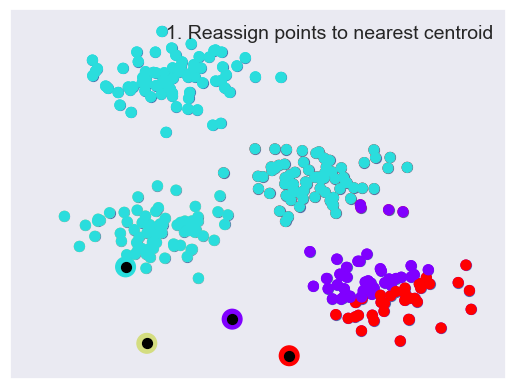

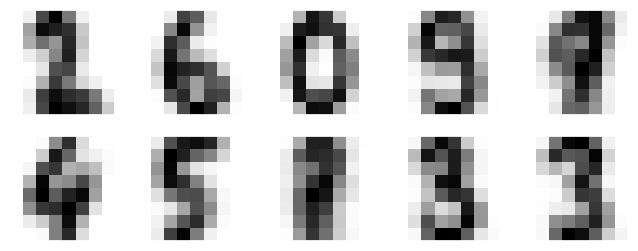

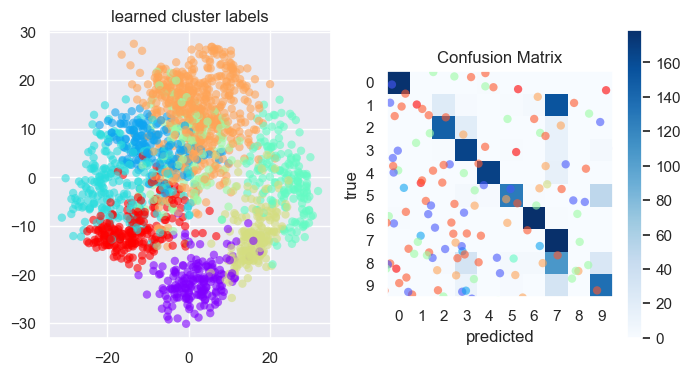

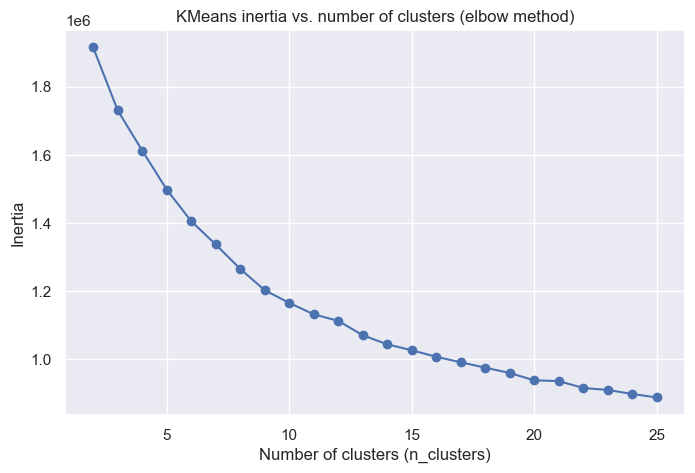

In [37]:
# Plot KMeans inertia as a function of n_clusters (the "elbow" method).
n_range = range(2, 26)                 # candidate cluster counts: 2, 3, ..., 25
inertias = []                          # will collect the inertia for each n_clusters
for k in n_range:                      # loop over each candidate number of clusters
    km = KMeans(n_clusters=k, n_init=10, random_state=0)  # fresh KMeans with k clusters
    km.fit(digits.data)                # fit on the 64-dimensional digit data
    inertias.append(km.inertia_)       # store the within-cluster sum of squared distances

plt.figure(figsize=(8, 5))                                  # new figure
plt.plot(list(n_range), inertias, marker='o')               # inertia vs. number of clusters
plt.xlabel('Number of clusters (n_clusters)')               # x-axis label
plt.ylabel('Inertia')                                       # y-axis label
plt.title('KMeans inertia vs. number of clusters (elbow method)')  # title
plt.show()                                                  # render the plot


**Observation.** The inertia decreases monotonically as `n_clusters` goes up. Adding more centroids only shirnks the within-cluster squared distances. The drop seems pretty steep but then flattens out, with the elbow at around `k ≈ 10`, which matches the ten true digit classes. This also seems to be an adequate trade-off b/w compactness and complexity. In the extreme `n_clusters = digits.data.shape[0]` (one cluster per sample), every point is its own centroid, so all distances vanish and the **inertia is 0**.

## Example: KMeans for Color Compression

One interesting application of clustering is in color image compression. For example, imagine you have an image with millions of colors. In most images, a large number of the colors will be unused, and conversely a large number of pixels will have similar or identical colors.

Scikit-learn has a number of images that you can play with, accessed through the datasets module. For example:

In [38]:
from sklearn.datasets import load_sample_image
china = load_sample_image("china.jpg")
plt.imshow(china)
plt.grid(False);

The image itself is stored in a 3-dimensional array, of size ``(height, width, RGB)``:

In [39]:
print(f"Image shape: (height, width, RBG) {china.shape}")

Image shape: (height, width, RBG) (427, 640, 3)


We can envision this image as a cloud of points in a 3-dimensional color space. We'll rescale the colors so they lie between 0 and 1.

In [40]:
X = (china / 255.0)

**Question** Reshape the array to obtain a dataset of 3 dimensional points, each point representing one pixel.

In [41]:
# Reshape the (height, width, 3) image into a flat list of 3-D color points (one row per pixel).
# Using -1 lets NumPy infer the number of pixels (height * width) automatically.
data = X.reshape(-1, 3)
print(f"Pixel dataset shape (n_pixels, RGB): {data.shape}")  # expected (273280, 3)


Pixel dataset shape (n_pixels, RGB): (273280, 3)


We now have 273,280 points in 3 dimensions.

Our task is to use KMeans to compress the $256^3$ colors into a smaller number (say, 64 colors). Basically, we want to find $N_\mathrm{color}$ clusters in the data, and create a new image where the true input color is replaced by the color of the closest cluster.

**Question** Fit a k-means model to your newly generated dataset.

In [42]:
# Fit KMeans to find `n_colors` representative colors (cluster centers) in RGB space.
n_colors = 64                                              # number of colors to keep
kmeans = KMeans(n_clusters=n_colors, n_init=10, random_state=0)  # KMeans estimator
kmeans.fit(data)                                           # learn the 64 centroid colors from all pixels
print(f"Learned {kmeans.cluster_centers_.shape[0]} centroid colors in RGB space")


Learned 64 centroid colors in RGB space


**Question** Time to evaluate our compression model: replace each pixel in the original image by the value of its centroid. Then, display both images.

In [43]:
n_colors = 64
# Map every pixel to the color of the cluster center (centroid) it was assigned to.
labels = kmeans.predict(data)                  # nearest-centroid index for each pixel
new_colors = kmeans.cluster_centers_[labels]   # look up the centroid RGB color for each pixel
new_image = new_colors.reshape(X.shape)        # reshape the flat color list back to (h, w, 3)

# create and plot the new image
with sns.axes_style('white'):
    plt.figure()
    plt.imshow(china)
    plt.axis('off')
    plt.title('input: 16 million colors')

    plt.figure()
    plt.imshow(new_image)
    plt.axis('off')
    plt.title('{0} colors'.format(n_colors))


**Question** Repeat this process with ``MiniBatchKMeans`` (see [official documentation](https://scikit-learn.org/stable/modules/clustering.html#mini-batch-kmeans)), a more sophisticated estimator that performs better for larger datasets, and print the training time of both methods.

In [44]:
from sklearn.cluster import MiniBatchKMeans

In [45]:
import time                                       # used to measure training time

n_colors = 64

# --- Time the standard KMeans ---
t0 = time.time()                                  # start timer
km = KMeans(n_clusters=n_colors, n_init=10, random_state=0).fit(data)  # full-batch KMeans
kmeans_time = time.time() - t0                    # elapsed training time

# --- Time the MiniBatchKMeans (updates centroids on small random mini-batches) ---
t0 = time.time()                                  # restart timer
mbk = MiniBatchKMeans(n_clusters=n_colors, random_state=0).fit(data)   # mini-batch KMeans
mbk_time = time.time() - t0                       # elapsed training time

print(f"KMeans training time         : {kmeans_time:.3f} s")
print(f"MiniBatchKMeans training time: {mbk_time:.3f} s")

# Build the compressed image from the MiniBatchKMeans centroids
mbk_labels = mbk.predict(data)                    # assign each pixel to its nearest centroid
new_image = mbk.cluster_centers_[mbk_labels].reshape(X.shape)  # rebuild the (h, w, 3) image

# create and plot the new image
with sns.axes_style('white'):
    plt.figure()
    plt.imshow(china)
    plt.axis('off')
    plt.title('input: 16 million colors')

    plt.figure()
    plt.imshow(new_image)
    plt.axis('off')
    plt.title('{0} colors'.format(n_colors))


KMeans training time         : 23.713 s
MiniBatchKMeans training time: 0.255 s


**Observation.** `MiniBatchKMeans` trains a lot faster than full `KMeans` (it updates centroids on small random mini-batches rather than scanning all the data each iteration) while producing an image that basically looks the same. This makes it preferred on bigger data such as higher-res images.

**Question** Plot the distance between the two images as a function of $N_\mathrm{color} \in [10, 200]$.

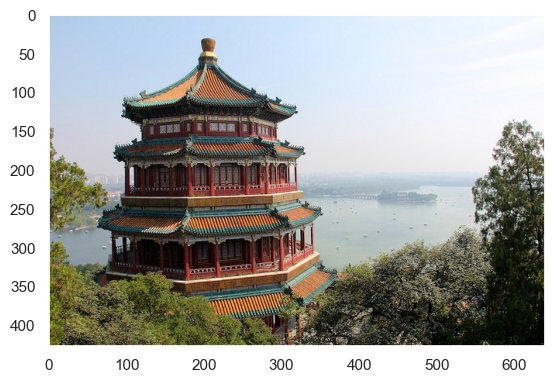

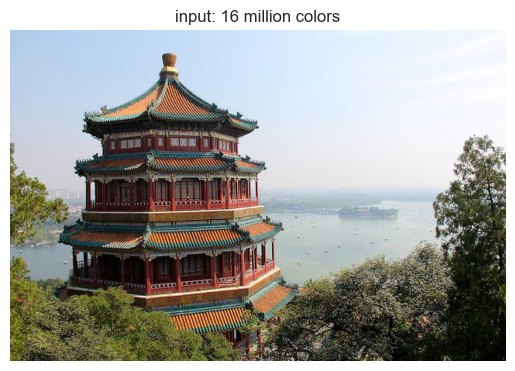

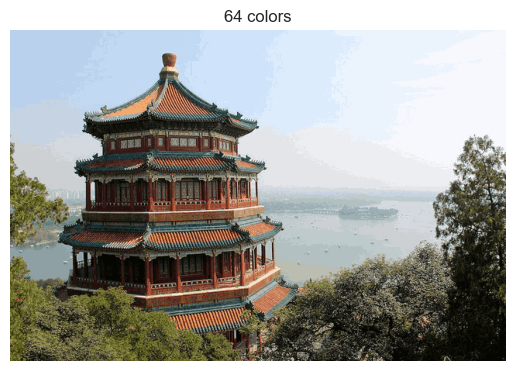

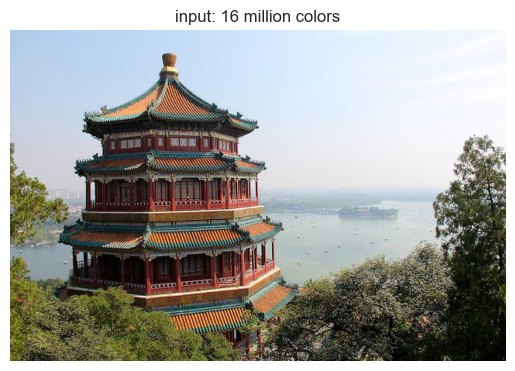

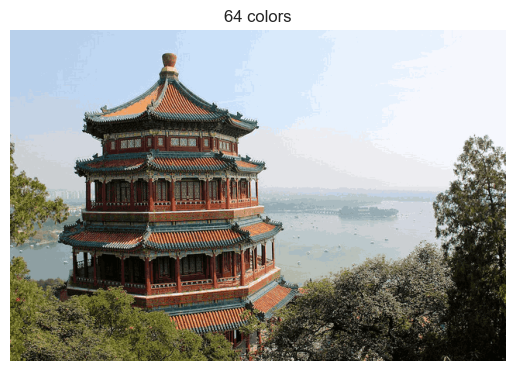

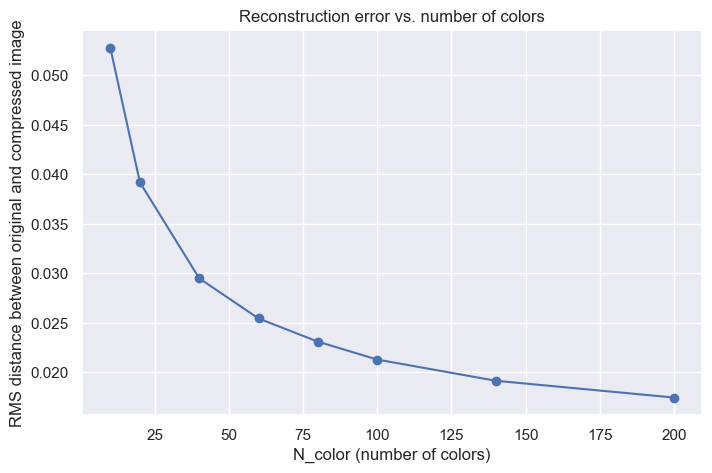

In [46]:
# Plot the distance between the original and compressed image as a function of N_color.
# We use MiniBatchKMeans (fast) and fit on a random subset of pixels, then predict on all pixels.
from sklearn.utils import shuffle

n_color_values = [10, 20, 40, 60, 80, 100, 140, 200]  # values of N_color to test in [10, 200]
distances = []                                         # RMS distance for each N_color

sample = shuffle(data, random_state=0)[:10000]         # 10k-pixel sample to speed up fitting

for n in n_color_values:                               # loop over each candidate color count
    mbk = MiniBatchKMeans(n_clusters=n, random_state=0).fit(sample)  # fit on the sample
    lab = mbk.predict(data)                            # assign every pixel to a centroid
    compressed = mbk.cluster_centers_[lab].reshape(X.shape)  # rebuild the compressed image
    dist = np.sqrt(np.mean((X - compressed) ** 2))     # RMS (Euclidean) distance between images
    distances.append(dist)                             # store the distance

plt.figure(figsize=(8, 5))
plt.plot(n_color_values, distances, marker='o')
plt.xlabel('N_color (number of colors)')
plt.ylabel('RMS distance between original and compressed image')
plt.title('Reconstruction error vs. number of colors')
plt.show()


**Observation.** The distance falls steeply as `N_color` increases and then levels off: the first few dozen colors capture most of the image's color variation, but enlarging the palette beyond ~100 colors barely improves. This mirrors the inertia "elbow" from before, earlier in the lab, showing how well a finite set of centroids estimates data.

## Other clustering algorithms:
- check out scikit learn library
- some more sophisticated algorithms use kmeans as a subroutine, e.g., spectral clustering